# Hypothesis test 1

## import data 

In [ ]:
library(dplyr)
library(emmeans)
library(car)
library(ggplot2)
library(tidyr)
library(tibble)
library(boot)
library(PrettyCols)
library(lmtest)

In [35]:
fulldata = read.csv("/Users/emmal/Library/CloudStorage/OneDrive-Personal/Documents/Schule/Cambridge/PART II/PBS5/CODE/VisualSearchLLM/veo_results/mergedVeo3.csv", stringsAsFactors =T)
groupeddata = read.csv("/Users/emmal/Library/CloudStorage/OneDrive-Personal/Documents/Schule/Cambridge/PART II/PBS5/CODE/VisualSearchLLM/veo_results/generative_success.csv", stringsAsFactors = T)

condition_labels <- c(
  "2Among5Colour"   = "Colour Disjunctive",
  "2Among5NoColour" = "Shape Conjunctive",
  "2Among5ConjRed"  = "Shape & Colour Conjunctive"
)
bin_labels <- c(
  "1"  = "1\n(1–4)",
  "2"  = "2\n(5–8)",
  "3"  = "3\n(9–16)",
  "4"  = "4\n(17–32)",
  "5"  = "5\n(33–64)",
  "6"  = "6\n(65–99)"
)
colours <- c(
  '2Among5Colour'    = "#9B69FF",
  '2Among5ConjRed'   = "#DFC12F",
  '2Among5NoColour'  = "#F84AC1"
)


In [ ]:
fulldata = fulldata %>% filter(condition != "NoDistractors")
fulldata$bin_group = as.factor(fulldata$bin_group)
fulldata$condition <- droplevels(fulldata$condition)
table(fulldata$success)
table(fulldata$condition)
table(fulldata$bin_group)

fulldata$condtion = as.factor(fulldata$condition)
fulldata$bin_group = as.integer(fulldata$bin_group)
fulldata$video_filename = as.factor(fulldata$video_filename)
class(fulldata$bin_group)   

## Assumption testing

, ,  = 1

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             1              1               2
  1             5              5               4

, ,  = 2

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             2              6               6
  1             4              0               0

, ,  = 3

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             4              5               5
  1             2              1               1

, ,  = 4

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             4              6               6
  1             2              0               0

, ,  = 5

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             5              6               6
  1             1              0               0

, ,  = 6

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             3              6               6
  1             3              0               0


Model :
success ~ condition * bin_group


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
condition,33.422511,2,2.404417
bin_group,1.617035,1,1.271627
condition:bin_group,26.227688,2,2.263028


,GVIF,Df,GVIF^(1/(2*Df))
condition,1.179457,2,1.042127
bin_group,1.179457,1,1.086028


,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
71,2.7533225,0.06610700,0.25847710
75,0.8565307,0.14485672,0.01306034
90,0.8565307,0.14485672,0.01306034
91,2.8972654,0.06797507,0.33082150


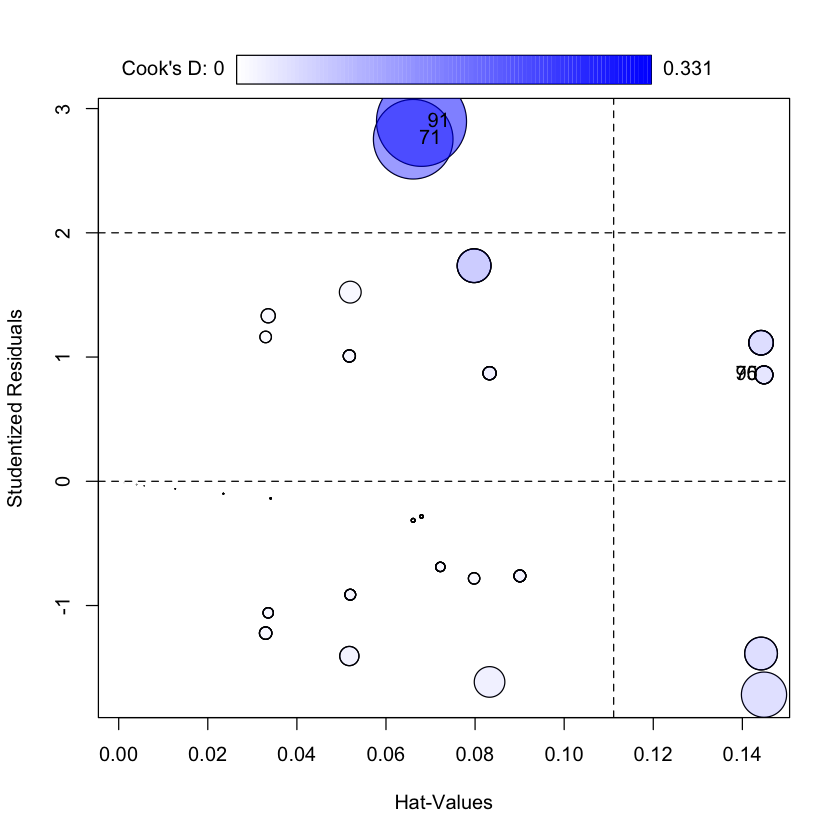

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
5,2.184556,0.04002795,0.08870675
9,2.184556,0.04002795,0.08870675
38,-1.019514,0.07705825,0.01441476
47,-1.019514,0.07705825,0.01441476


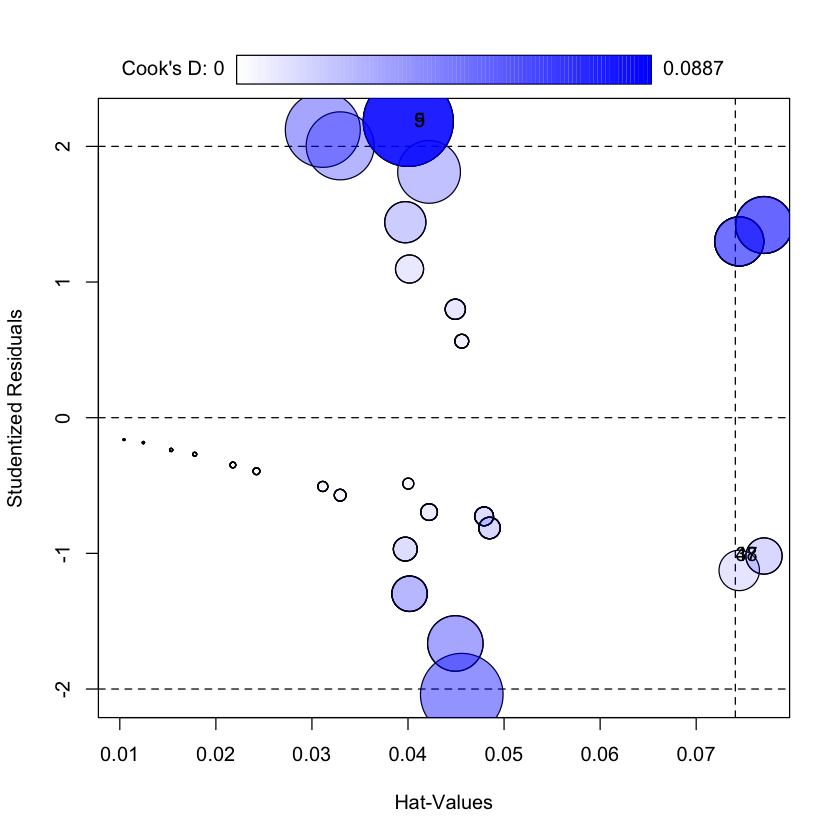

In [7]:
modelRQ1 = glm(success ~condition*bin_group, data = fulldata, family = binomial(link = "logit"))
smallmodelRQ1 = glm(success ~ condition + bin_group, data   = fulldata, family = binomial(link = "logit"))
# separation (OK)
table(fulldata$success, fulldata$condition, fulldata$bin_group)
# multicollinearity of IVs - < 10 (likley ok; GVIF for df= 1 ok, ADjusted GVIF^(1/2*df) < sqrt(threshold))
alias(modelRQ1)
car::vif(modelRQ1)
car::vif(smallmodelRQ1)
# linearity of log odds - only for continuous 
# DV is binominal
# uniqueness of observations (for now) assumed
# Sample size at least 10 per term = not given but cannot change (success = 28; fail = 80) <- given DF = 17 issue partially 
# outliers = cooks distance is OK
influencePlot(modelRQ1, id=T)
influencePlot(smallmodelRQ1, id = T)

## Run model(S)

In [9]:
## alt consideration of the factor version of bin group
fullmodelRQ1_factor = glm(success ~ condition*as.factor(bin_group), data = fulldata, family = binomial(link = "logit"))
anova(fullmodelRQ1_factor, modelRQ1, test = "Chisq")
# factor version is not significantly better than the model with bin group as numeric, so we can keep the simpler model (with bin group as numeric)

# drop1(modelRQ1, test = "Chisq")
anova(modelRQ1, smallmodelRQ1, test = "Chisq")
## as significant diff of models; keep interaction model

summary(modelRQ1)
print(pchisq((modelRQ1$null.deviance - modelRQ1$deviance), (modelRQ1$df.null - modelRQ1$df.residual), lower.tail = FALSE))
cat("\n  delta x^2 = " , round((modelRQ1$null.deviance - modelRQ1$deviance), digits = 3) , "\n")
cat("\n  Odds ratios (exp(coef)):\n")
print(round(exp(cbind(OR = coef(modelRQ1), confint(modelRQ1))), 3))


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,90,65.90412,NA,NA,NA
2,102,79.73089,-12,-13.82677,0.3119069


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,102,79.73089,NA,NA,NA
2,104,88.51968,-2,-8.788788,0.01234636



Call:
glm(formula = success ~ condition * bin_group, family = binomial(link = "logit"), 
    data = fulldata)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)  
(Intercept)                          1.2252     0.8148   1.504   0.1327  
condition2Among5ConjRed              1.7826     1.7846   0.999   0.3179  
condition2Among5NoColour             0.7181     1.6070   0.447   0.6550  
bin_group                           -0.3852     0.2138  -1.802   0.0715 .
condition2Among5ConjRed:bin_group   -1.6952     0.9164  -1.850   0.0643 .
condition2Among5NoColour:bin_group  -1.2687     0.7992  -1.587   0.1124  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 123.613  on 107  degrees of freedom
Residual deviance:  79.731  on 102  degrees of freedom
AIC: 91.731

Number of Fisher Scoring iterations: 7


[1] 2.44785e-08

  delta x^2 =  43.882 

  Odds ratios (exp(coef)):


Waiting for profiling to be done...



                                      OR 2.5 %  97.5 %
(Intercept)                        3.405 0.730  18.972
condition2Among5ConjRed            5.945 0.248 365.113
condition2Among5NoColour           2.051 0.104  68.863
bin_group                          0.680 0.433   1.015
condition2Among5ConjRed:bin_group  0.184 0.018   0.741
condition2Among5NoColour:bin_group 0.281 0.037   0.960


## post hock testing

In [10]:
# post-hoc tests for bin effects within each condition (Each row tests H₀: slope = 0)
trends_RQ1 <- emtrends(modelRQ1, 
                       specs = ~ condition, 
                       var   = "bin_group")
summary(trends_RQ1, infer = c(TRUE, TRUE))
# => set sixe effect in condition ?
# paiwise contrasts for slope diffrerences across conditions 
trends_RQ1_pairs <- emtrends(modelRQ1, pairwise ~ condition, var = "bin_group")
summary(trends_RQ1_pairs$contrasts, infer = c(TRUE, TRUE))
# => conditions differ in steepness of slope ? 
## results show no significant differences in slope across conditions, but a significant slope in the NOColour & Conjunctive condition (and non-significant slope in simple colour condition).

# Polynimical contrasts 
## by bin group trend structures across conditions - check for linear = specified post hock test of most interest! 
bin_RQ1_structure = emmeans(modelRQ1, specs = ~ condition | bin_group) %>%
  contrast("poly")
summary(bin_RQ1_structure, infer = c(TRUE, TRUE))
## RESULTS SHOW: sig. linear trend; non sig. quadrratic trend


,condition,bin_group.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour,-0.3852178,0.2137720,Inf,-0.8042032,0.0337677,-1.802003,0.07154498
2,2Among5ConjRed,-2.0803919,0.8911169,Inf,-3.8269490,-0.3338348,-2.334589,0.01956489
3,2Among5NoColour,-1.6539462,0.7700982,Inf,-3.1633109,-0.1445815,-2.147708,0.03173695


,contrast,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour - 2Among5ConjRed,1.6951741,0.9163994,Inf,-0.4525917,3.842940,1.8498202,0.1535842
2,2Among5Colour - 2Among5NoColour,1.2687284,0.7992182,Inf,-0.6043997,3.141857,1.5874619,0.2510246
3,2Among5ConjRed - 2Among5NoColour,-0.4264457,1.1777693,Inf,-3.1867844,2.333893,-0.3620791,0.9302890


,contrast,bin_group,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,linear,3.5,-3.722432,1.605462,Inf,-6.86908,-0.575785,-2.318605,0.02041645
2,quadratic,3.5,4.578680,3.892010,Inf,-3.04952,12.206881,1.176431,0.23942286


In [17]:
# Failure types 
print(table(fulldata$failure_type, useNA = "ifany"))
failures_df <- fulldata %>%
  filter(success == 0, !is.na(failure_type))  # exclude bin 0 if that = no distractors

failure_ct <- table(failures_df$failure_type, failures_df$condition)
print(failure_ct)

# No-distractor condition — reported descriptively
nodist_failures <- fulldata %>%
  filter(success == 0, failure_type == "No Distractors")

cat("\nNo-distractor failures (descriptive only):\n")
print(table(nodist_failures$condition))

# Check expected cell counts
expected <- chisq.test(failure_ct)$expected
cat(sprintf("\nMinimum expected count: %.2f\n", min(expected)))

# Choose test accordingly
if (min(expected) >= 5) {
  cat("Using Pearson chi-square\n")
  print(chisq.test(failure_ct))
} else {
  cat("Using Fisher-Freeman-Halton exact test\n")
  print(fisher.test(failure_ct, simulate.p.value = TRUE, B = 10000))
}



                    ambiguity       location new_generation 
            28             15              2             63 
                
                 2Among5Colour 2Among5ConjRed 2Among5NoColour
                             0              0               0
  ambiguity                 12              1               2
  location                   0              1               1
  new_generation             7             28              28

No-distractor failures (descriptive only):

  2Among5Colour  2Among5ConjRed 2Among5NoColour 
              0               0               0 


Warning message in chisq.test(failure_ct):
“Chi-squared approximation may be incorrect”



Minimum expected count: 0.00
Using Fisher-Freeman-Halton exact test

	Fisher's Exact Test for Count Data with simulated p-value (based on
	10000 replicates)

data:  failure_ct
p-value = 9.999e-05
alternative hypothesis: two.sided



### visualisation

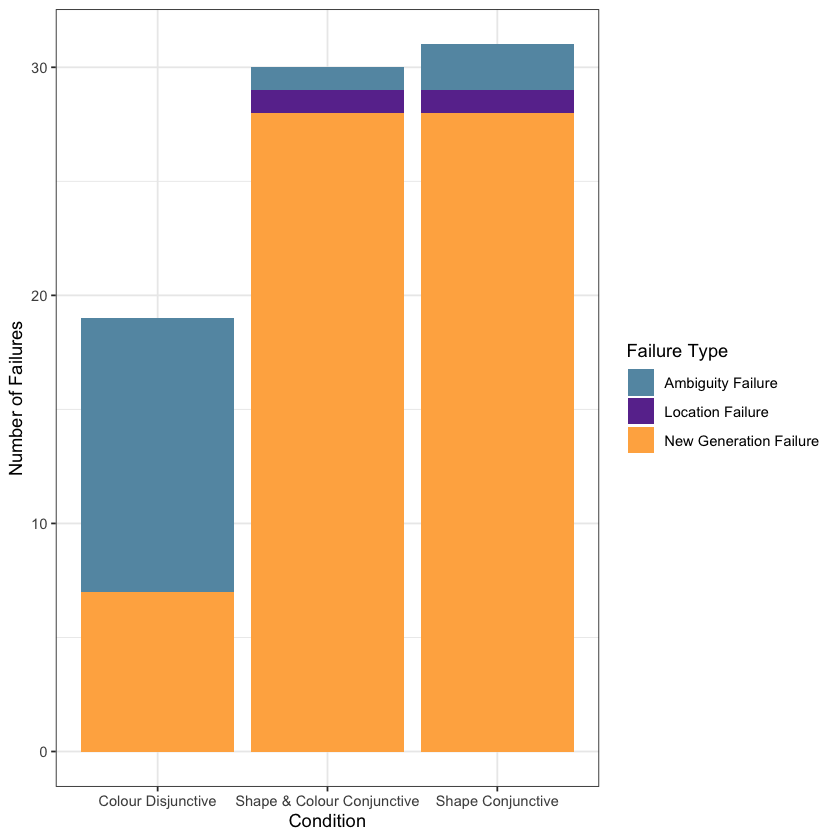

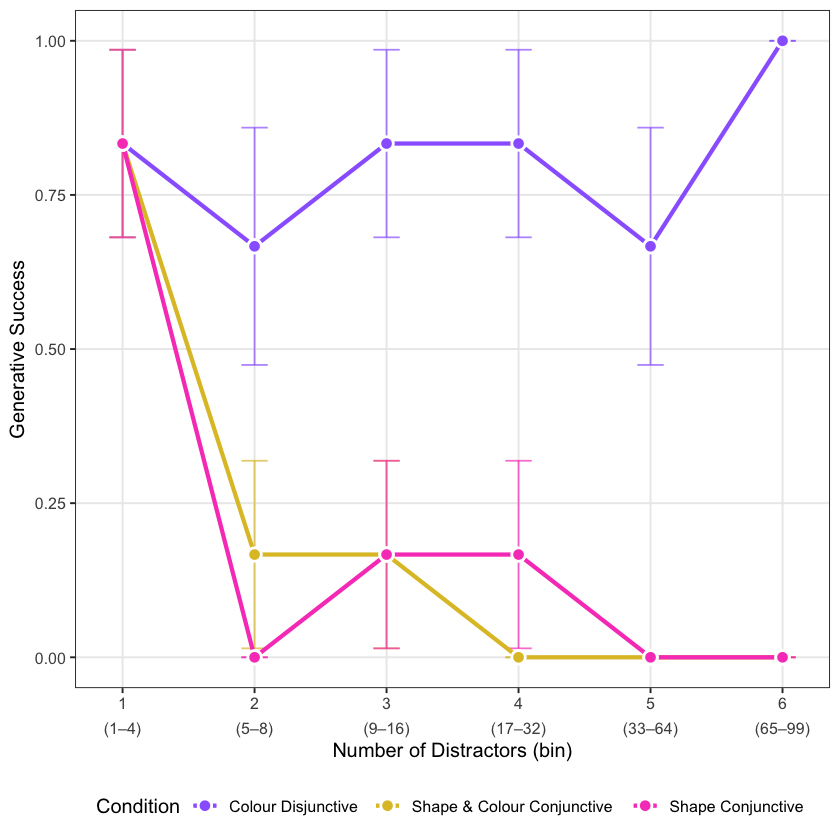

In [36]:
failure_labels <- c(
  "ambiguity" = "Ambiguity Failure",
  "location"    = "Location Failure",
  "new_generation" = "New Generation Failure"
)
ggplot(failures_df, aes(x = condition, fill = failure_type)) +
  geom_bar(position = "stack") +
  scale_fill_pretty_d("Bold", labels = failure_labels ) +
  scale_x_discrete(labels = condition_labels) +
  labs(
    x = "Condition",
    y = "Number of Failures",
    fill = "Failure Type"
  ) +
  theme_bw()

groupeddata = groupeddataAS %>% filter(condition != "NoDistractors")
ggplot(groupeddata, 
       aes(x      = bin, 
           y      = generative_success,
           colour = condition)) +
  geom_errorbar(aes(ymin = generative_success - se_success,
                    ymax = generative_success + se_success),
                width     = 0.2,
                linewidth = 0.5,
                alpha     = 0.7) +
  geom_line(linewidth = 1.2) +
  geom_point(size   = 3,
             shape  = 21,
             aes(fill = condition),
             colour = "white",
             stroke = 1.2) +
  scale_colour_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_fill_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_x_continuous(
    breaks = 1:6,
    labels = bin_labels
  ) +
  labs(x      = "Number of Distractors (bin)",
       y      = "Generative Success",
       colour = "Condition",
       fill   = "Condition") +
  theme_minimal(base_size = 13) +
  theme_bw(base_size = 12)+
  theme(
    legend.position  = "bottom",
    strip.text       = element_text(face = "bold", size = 12),
    panel.grid.minor = element_blank(),
    panel.spacing    = unit(1.5, "lines"),
    plot.title       = element_text(face = "bold", hjust = 0.5),
    axis.text.x      = element_text(lineheight = 1.3)
  )


## Firths version

### assumptions

In [ ]:
# issue 1 somse cells will show full separation
# high separation for some points issue 
# Events per variable (EPV) — rule of thumb >= 10 per parameter , not iven hence penalised regression (Firth's logistic regression)

### model

In [ ]:
fulldata$bin_group = as.integer(fulldata$bin_group)
library(logistf)
modelRQ1_firth = logistf(success ~ condition*bin_group, data = fulldata)
summary(modelRQ1_firth)

In [ ]:
#odds ratio/ CIs
data.frame(
  OR    = exp(coef(modelRQ1_firth)),
  CI_lo = exp(modelRQ1_firth$ci.lower),
  CI_hi = exp(modelRQ1_firth$ci.upper),
  p     = modelRQ1_firth$prob
) %>%
  round(3) %>%
  print()

In [ ]:
# Compare to standard logistic regression results
comparison_ModelsRQ1 = data.frame(parameter = names(coef(modelRQ1_firth)),
                                    glm_coef = round(coef(modelRQ1), 3),
                                    firth_coef = round(coef(modelRQ1_firth), 3),
                                    difference = round(coef(modelRQ1) - coef(modelRQ1_firth), 3))  
print(comparison_ModelsRQ1)

# Hypothesis 2 

## import data 

In [11]:
humandata = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/HumanData.csv", stringsAsFactors = T)
print(colnames(humandata))
table(humandata$shape_type)
table(humandata$target_color)
table(humandata$distractor_color)

 [1] "PID"              "trial"            "response"         "rt"              
 [5] "accuracy"         "display"          "filename"         "shape_type"      
 [9] "colour_type"      "target_color"     "distractor_color" "quadrant"        
[13] "num_distractors"  "answer"           "distractor_bin"   "bin_group"       



   2    5 
2160 2160 


 blue green   red 
 1440  1440  1440 


 blue green   red 
 1440  1440  1440 

### test for colour/ identity effects as of coundernbalancing = gaps 

In [ ]:
chisq.test(table(humandata$shape_type, humandata$accuracy))
chisq.test(table(humandata$target_color, humandata$accuracy))
chisq.test(table(humandata$distractor_color, humandata$accuracy))

# not significant target and shape effects, distractor may be confounded by search condition hence I choose to proceed with the full data set to omit issues with the missing data otherwise


## descriptive

In [12]:
generative_veo_success = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/generative_success.csv", stringsAsFactors = T)
Veo_summary <- generative_veo_success %>% filter(condition != "NoDistractors") %>%
  rename(
    bin_group    = bin,
    mean_acc_veo = generative_success,
    se_veo       = std_success
  ) %>%
  mutate(
    condition = as.character(condition),
    bin_group = as.integer(bin_group)
  ) %>%
  select(condition, bin_group, mean_acc_veo, se_veo, ci_lower, ci_upper)

Human_summary <- humandata %>%
  group_by(colour_type, bin_group) %>%
  summarise(
    mean_acc_human = mean(accuracy, na.rm = TRUE),
    n              = n(),
    se_human       = sqrt(mean_acc_human * (1 - mean_acc_human) / n),
    .groups        = "drop"
  ) %>%
  rename(condition = colour_type) %>%
  mutate(
    condition = as.character(condition),
    bin_group = as.integer(bin_group)
  ) %>%
  select(condition, bin_group, mean_acc_human, se_human)

combined_wide <- Veo_summary %>%
  full_join(Human_summary, by = c("condition", "bin_group"))

print(head(combined_wide))

      condition bin_group mean_acc_veo    se_veo    ci_lower  ci_upper
1 2Among5Colour         1    0.8333333 0.4082483  0.53512883 1.1315378
2 2Among5Colour         2    0.6666667 0.5163978  0.28946449 1.0438688
3 2Among5Colour         3    0.3333333 0.5163978 -0.04386884 0.7105355
4 2Among5Colour         4    0.3333333 0.5163978 -0.04386884 0.7105355
5 2Among5Colour         5    0.1666667 0.4082483 -0.13153784 0.4648712
6 2Among5Colour         6    0.5000000 0.5477226  0.09991668 0.9000833
  mean_acc_human    se_human
1      0.9833333 0.008263597
2      0.9666667 0.011587030
3      0.9750000 0.010077822
4      0.9708333 0.010862008
5      0.9833333 0.008263597
6      1.0000000 0.000000000


### plotting

      condition bin_group    se_veo    ci_lower  ci_upper    se_human agent
1 2Among5Colour         1 0.4082483  0.53512883 1.1315378 0.008263597   Veo
2 2Among5Colour         2 0.5163978  0.28946449 1.0438688 0.011587030   Veo
3 2Among5Colour         3 0.5163978 -0.04386884 0.7105355 0.010077822   Veo
4 2Among5Colour         4 0.5163978 -0.04386884 0.7105355 0.010862008   Veo
5 2Among5Colour         5 0.4082483 -0.13153784 0.4648712 0.008263597   Veo
6 2Among5Colour         6 0.5477226  0.09991668 0.9000833 0.000000000   Veo
   mean_acc        se
1 0.8333333 0.4082483
2 0.6666667 0.5163978
3 0.3333333 0.5163978
4 0.3333333 0.5163978
5 0.1666667 0.4082483
6 0.5000000 0.5477226

Human   Veo 
   18    18 


Ignoring unknown labels:
• fill : "Condition"
Ignoring unknown labels:
• fill : "Condition"


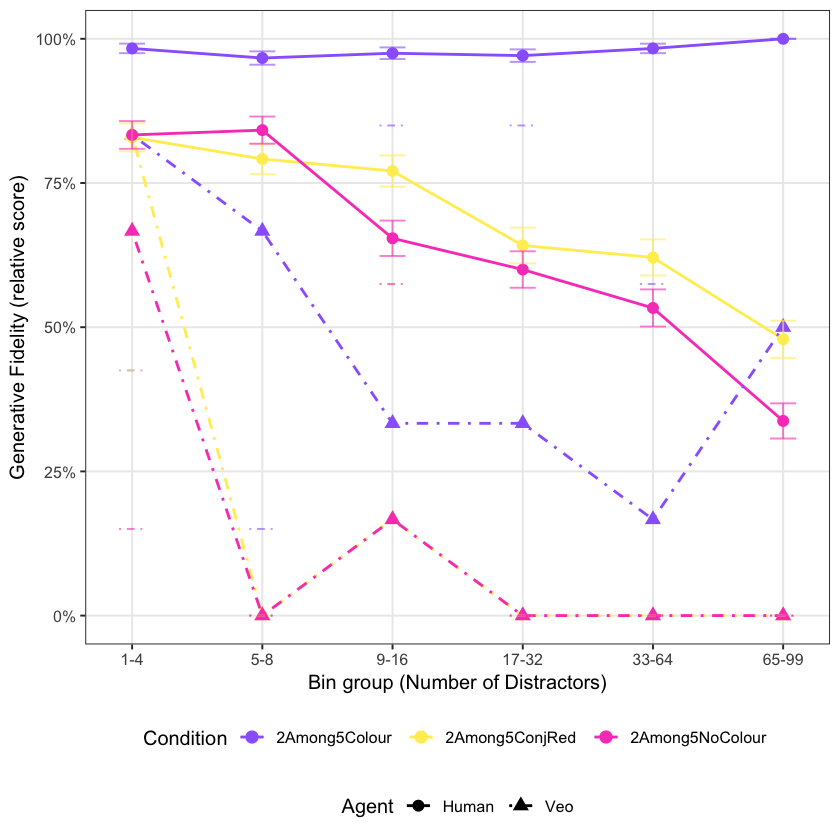

In [13]:
combined_long <- combined_wide %>%
  gather(key = "agent", value = "mean_acc", mean_acc_veo, mean_acc_human) %>%
  mutate(
    se    = ifelse(agent == "mean_acc_veo", se_veo, se_human),
    agent = ifelse(agent == "mean_acc_veo", "Veo", "Human")
  )
print(head(combined_long))
print(table(combined_long$agent, useNA = "ifany"))

condition_colours <- c(
  "2Among5Colour"   = "#9B69FF",
  "2Among5ConjRed"  = "#FFED61",
  "2Among5NoColour" = "#F84AC1"
)

ggplot(combined_long, 
       aes(x        = bin_group, 
           y        = mean_acc,
           colour   = condition,
           linetype = agent,
           shape = agent,
           group    = interaction(condition, agent))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_acc - se,
                    ymax = mean_acc + se),
                width = 0.2, alpha = 0.6) +
  scale_colour_manual(values = condition_colours) +
  scale_x_continuous(
    breaks = 1:6,
    labels = c("1-4", "5-8", "9-16", "17-32", "33-64", "65-99")
  ) +
  scale_y_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  scale_linetype_manual(values = c(
    "Human" = "solid",
    "Veo"   = "dotdash"
  )) +
  scale_shape_manual(values = c(
    "Human" = 16,
    "Veo"   = 17
  )) +
  labs(
    x        = "Bin group (Number of Distractors)",
    y        = "Generative Fidelity (relative score)",
    colour   = "Condition",
    fill     = "Condition",
    linetype = "Agent",
    shape    = "Agent"
  ) +
  theme_bw(base_size = 12) +
  theme(
    legend.position  = "bottom",
    legend.box       = "vertical",
    panel.grid.minor = element_blank()
  )

ggsave("fig_Veo_vs_Human.png", width = 8, height = 5, dpi = 150)

## by modelling (agent as a fixed effect)

In [14]:
humanAndVeo = bind_rows(fulldata %>% 
    select(success, condition, bin_group) %>% 
    mutate(agent = "Veo"),
    humandata %>% select(accuracy, colour_type, bin_group) %>% 
    rename(success = accuracy, condition = colour_type) %>%
    mutate(agent = "Human")
) %>%
  mutate(
    agent     = factor(agent, levels = c("Human", "Veo")),  # Human as reference
    condition = as.character(condition),
    condition = factor(condition),
    bin_group = as.integer(bin_group)
  )
table(humanAndVeo$agent, humanAndVeo$condition, useNA = "ifany")

       
        2Among5Colour 2Among5ConjRed 2Among5NoColour
  Human          1440           1440            1440
  Veo              36             36              36

### test assumptions


, ,  = 1

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             5             42              42
  1           241            204             204

, ,  = 2

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            10             56              44
  1           236            190             202

, ,  = 3

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            10             60              88
  1           236            186             158

, ,  = 4

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            11             92             102
  1           235            154             144

, ,  = 5

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             9             97             118
  1           237            149             128

, ,  = 6

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             3            131             165
  1           243            115              81


Model :
success ~ agent * condition * bin_group


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
agent,10.704665,1,3.271798
condition,36.955691,2,2.465587
bin_group,21.615521,1,4.649249
agent:condition,60.614749,2,2.790259
agent:bin_group,7.780207,1,2.789302
condition:bin_group,185.465837,2,3.690337
agent:condition:bin_group,40.237883,2,2.518598


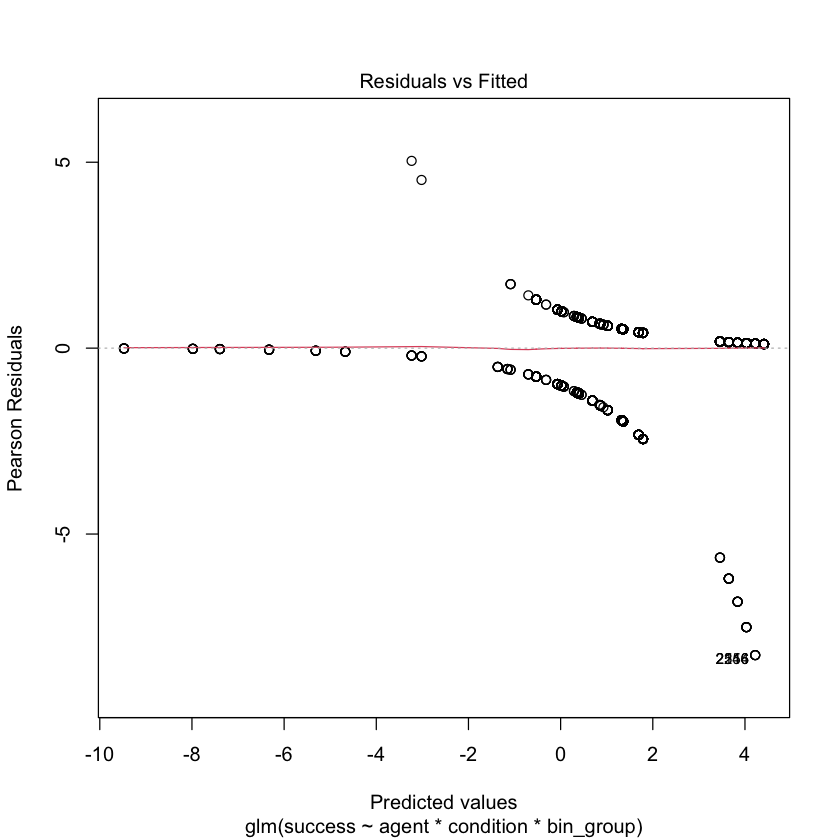

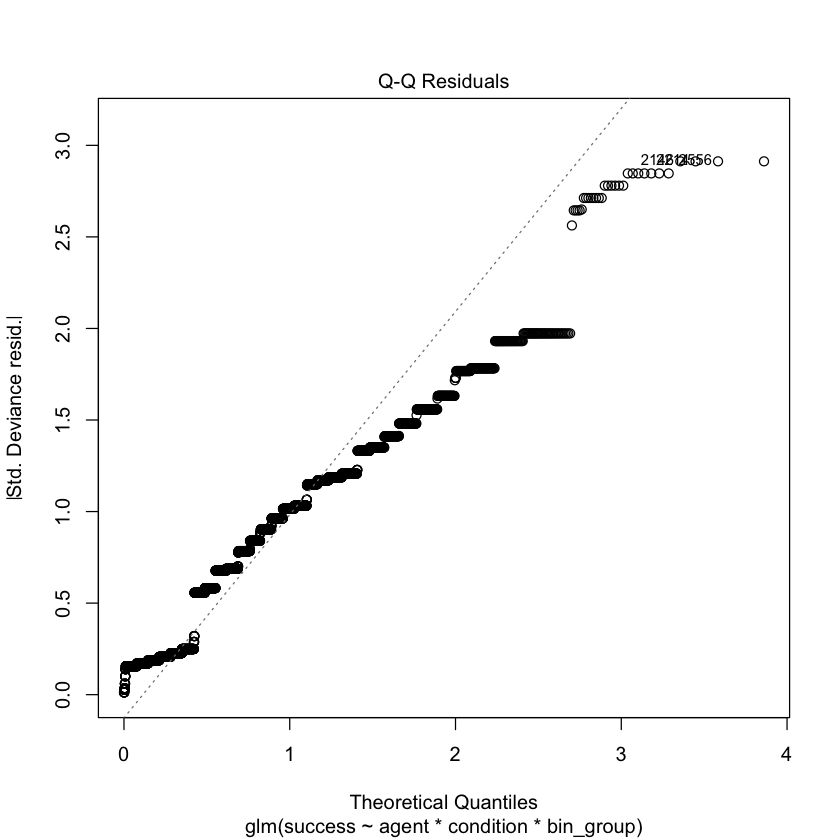

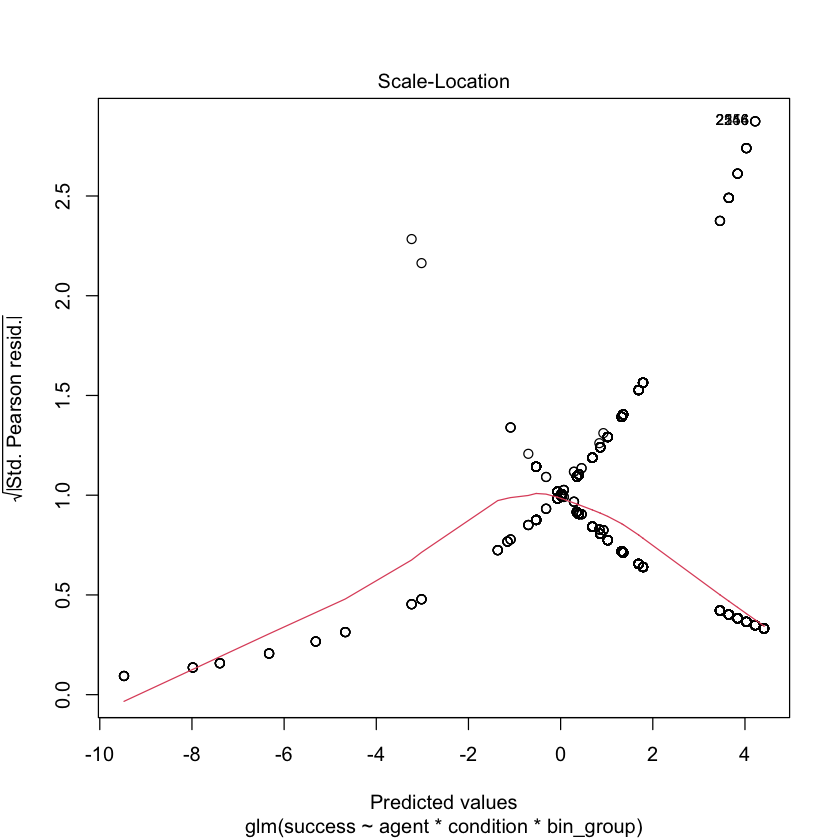

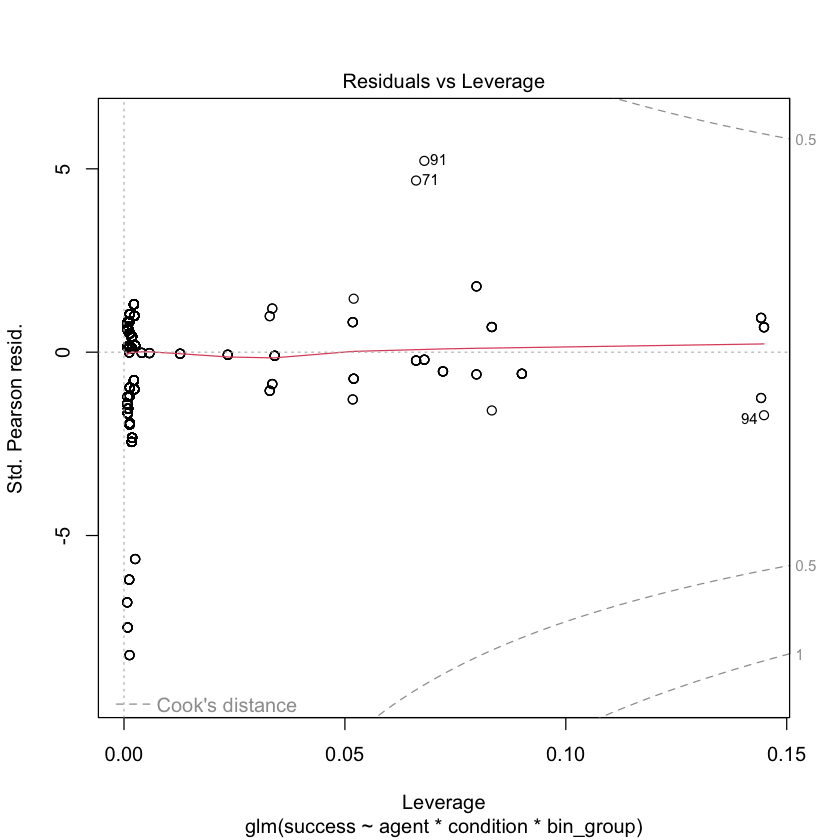

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
71,2.7533225,0.066107002,0.129238548
75,0.8565307,0.144856717,0.006530171
90,0.8565307,0.144856717,0.006530171
91,2.8972654,0.067975065,0.165410749
2146,-2.9255104,0.001253652,0.007139356
2214,-2.9255104,0.001253652,0.007139356



Call:
glm(formula = success ~ agent * condition * bin_group, family = binomial(link = "logit"), 
    data = humanAndVeo)

Coefficients:
                                            Estimate Std. Error z value
(Intercept)                                   3.2665     0.3864   8.454
agentVeo                                     -2.0413     0.9018  -2.264
condition2Among5ConjRed                      -1.2400     0.4145  -2.991
condition2Among5NoColour                     -1.0147     0.4151  -2.444
bin_group                                     0.1911     0.1135   1.684
agentVeo:condition2Among5ConjRed              3.0225     1.8321   1.650
agentVeo:condition2Among5NoColour             1.7328     1.6598   1.044
agentVeo:bin_group                           -0.5763     0.2420  -2.381
condition2Among5ConjRed:bin_group            -0.5256     0.1190  -4.418
condition2Among5NoColour:bin_group           -0.6550     0.1192  -5.496
agentVeo:condition2Among5ConjRed:bin_group   -1.1695     0.9241  -1.266

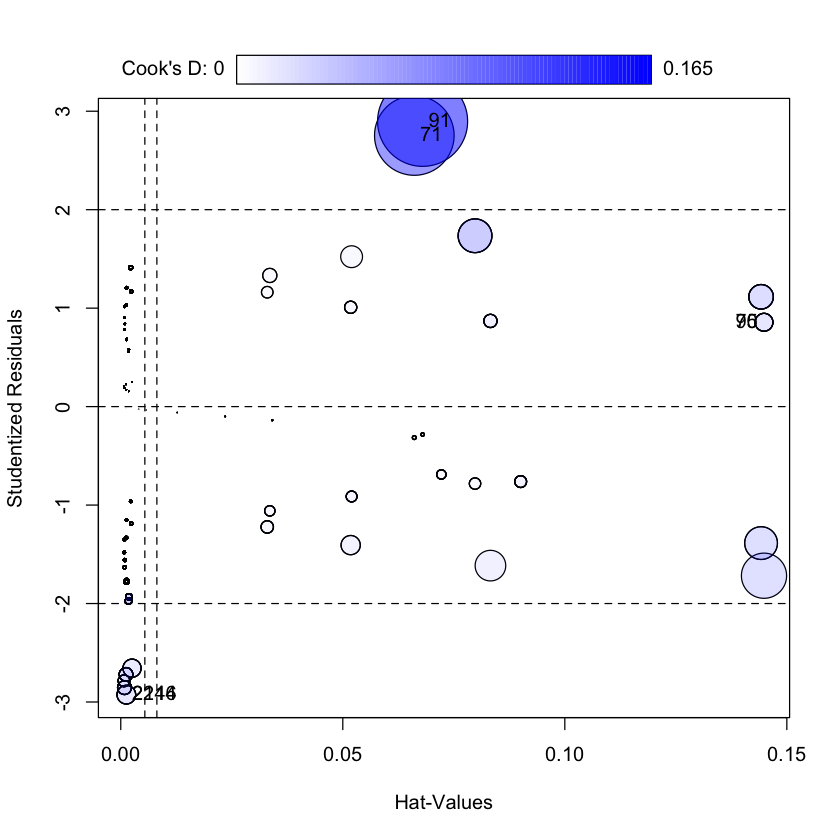

In [15]:
model_RQ2 = glm(success ~agent*condition*bin_group, data = humanAndVeo, family = binomial(link = "logit"))
# assumption test
# separation (OK)
table(humanAndVeo$success, humanAndVeo$condition, humanAndVeo$bin_group)
# multicollinearity of IVs - VIOLATED ==DISCUSS WHAT TO DO !! 
alias(model_RQ2)
car::vif(model_RQ2)
# linearity of log odds - only for continuous 
# DV is binominal
# uniqueness of observations (for now) assumed
# Sample size at least 10 per term = not given but cannot change (success = 28; fail = 80) <- given DF = 17 issue partially 
# outliers = cooks distance is OK
plot(model_RQ2)
influencePlot(model_RQ2, id=T)
# run model
summary(model_RQ2)
# ? as collapesd the individual condition/ bin varables not ineterpretable? 
# Need to consider how to report 

In [ ]:
# test smaller model alternative
model_n3way_RQ2 = glm(success ~ agent * condition + 
                        agent * bin_group + 
                        condition * bin_group,
          family = binomial, data = humanAndVeo)

summary(model_n3way_RQ2)
# AIC decreases hence  the data do not provide good evidence that it should be included.


In [ ]:
# spearman rank correlatoin
performance_vectors <- humanAndVeo %>%
  group_by(agent, condition, bin_group) %>%
  summarise(
    mean_acc = mean(success, na.rm = TRUE),
    .groups  = "drop"
  ) %>%
  group_by(agent) %>%
  mutate(mean_acc_centred = mean_acc - mean(mean_acc, na.rm = TRUE)) %>%
  ungroup()
# mean centering 
vectors_wide <- performance_vectors %>%
  select(condition, bin_group, agent, mean_acc_centred) %>%
  pivot_wider(names_from  = agent,
              values_from = mean_acc_centred) %>%
  arrange(condition, bin_group)

spearman_res <- cor.test(
  vectors_wide$Veo,
  vectors_wide$Human,
  method = "spearman",
)
print(spearman_res)
# bootstrap confidence intervals for spearman correlation
set.seed(23)
boot_fn <- function(data, idx) {
  cor(data[idx, "Veo"], data[idx, "Human"], method = "spearman")
}

boot_res <- boot(
  data      = as.data.frame(vectors_wide),
  statistic = boot_fn,
  R         = 1000
)

boot_ci <- boot.ci(boot_res, type = "perc", conf = 0.95)

cat(sprintf(
  "\nSpearman ρ = %.3f  (p = %.4f)\n95%% bootstrap CI [%.3f, %.3f]\n",
  spearman_res$estimate,
  spearman_res$p.value,
  boot_ci$percent[4],
  boot_ci$percent[5]
))

# triallevel bootstraps
boot_fn_trials <- function(data, idx) {
  # Resample trials, recompute cell means, then correlate
  resampled <- data[idx, ]
  
  cell_means <- resampled %>%
    group_by(agent, condition, bin_group) %>%
    summarise(mean_acc = mean(success, na.rm = TRUE), .groups = "drop") %>%
    group_by(agent) %>%
    mutate(mean_acc_centred = mean_acc - mean(mean_acc, na.rm = TRUE)) %>%
    ungroup() %>%
    select(condition, bin_group, agent, mean_acc_centred) %>%
    pivot_wider(names_from = agent, values_from = mean_acc_centred) %>%
    drop_na()
  
  # Need both agents present
  if (nrow(cell_means) < 2) return(NA)
  
  cor(cell_means$Veo, cell_means$Human, method = "spearman")
}
boot_res_trials <- boot(
  data      = as.data.frame(humanAndVeo),
  statistic = boot_fn_trials,  # the trial-level function from previous message
  R         = 1000
)
boot_ci_trials <- boot.ci(boot_res_trials, type = "perc", conf = 0.95)
print(boot_ci_trials)

### plot

In [ ]:
vectors_wide %>%
  ggplot(aes(x = Human, y = Veo, colour = condition, label = bin_group)) +
  geom_point(size = 3) +
  geom_text(nudge_y = 0.02, size = 5) +
  geom_smooth(method = "lm", se = TRUE, 
              colour = "grey50", linetype = "dashed") +
  geom_hline(yintercept = 0, linetype = "dotted", alpha = 0.5) +
  geom_vline(xintercept = 0, linetype = "dotted", alpha = 0.5) +
  scale_colour_manual(values = c(
    "2Among5Colour"   = "#9B69FF",
    "2Among5ConjRed"  = "#FFED61",
    "2Among5NoColour" = "#F84AC1"
  )) +
  labs(
    title    = "Mean-centred performance vectors: Veo vs Human",
    subtitle = sprintf("Spearman ρ = %.3f, p = %.4f", 
                       spearman_res$estimate, 
                       spearman_res$p.value),
    x        = "Human (mean-centred accuracy)",
    y        = "Veo (mean-centred accuracy)",
    colour   = "Condition"
  ) +
  theme_bw(base_size = 12) +
  theme(legend.position = "bottom")

# Hypothesis 3

## descriptive

In [ ]:
# error type analysis - descriptive and inferential
# Filter to failed trials only, exclude no-distractor condition
failures_df <- fulldata %>%
  filter(success == 0)  # exclude bin 0 if that = no distractors

err_cols <- grep("^err_", names(fulldata), value = TRUE)

# Build contingency table: condition × failure type
errors_long <- failures_df %>%
  select(condition, all_of(err_cols)) %>%
  mutate(across(all_of(err_cols), as.numeric)) %>%

  pivot_longer(all_of(err_cols), 
               names_to  = "error_type", 
               values_to = "present") %>%
  filter(present == 1) %>%
  count(condition, error_type)

error_ct <- errors_long %>%
  pivot_wider(names_from  = condition, 
              values_from = n, 
              values_fill = 0) %>%
  column_to_rownames("error_type") %>%
  as.matrix()

print(error_ct)


### fisher test

In [ ]:
# Check expected cell counts
expected <- chisq.test(error_ct)$expected
cat(sprintf("\nMinimum expected count: %.2f\n", min(expected)))

# Choose test accordingly
if (min(expected) >= 5) {
  cat("Using Pearson chi-square\n")
  print(chisq.test(error_ct))
} else {
  cat("Using Fisher-Freeman-Halton exact test\n")
  print(fisher.test(error_ct, simulate.p.value = TRUE, B = 10000))
}

# Descriptive: no-distractor condition reported separately
nodist_failures <- fulldata %>%
  filter(success == 0, bin_group == 0) %>%   # adjust if coded differently
  select(condition, all_of(err_cols)) %>%
  mutate(across(all_of(err_cols), as.numeric)) %>%
  summarise(across(all_of(err_cols), ~ sum(.x, na.rm = TRUE))) %>%
  pivot_longer(everything(), 
               names_to  = "error_type", 
               values_to = "count") %>%
  filter(count > 0)

cat("\nNo-distractor failures (descriptive only):\n")
print(nodist_failures)

### load data

In [ ]:
## prep data for fidelity score analysis
n_possible <- length(err_cols)
print(colnames(fulldata))
Fidelity_Subset = fulldata  %>% select(success, video_filename, fidelity_score_total, condition, bin_group) %>% mutate(fidelity_relative = fidelity_score_total/n_possible)
Fidelity_Subset$bin_group <- as.integer(Fidelity_Subset$bin_group)
Fidelity_Plot = Fidelity_Subset %>%
  group_by(condition, bin_group) %>%
  summarise(
    mean_fidelity = mean(fidelity_relative, na.rm = TRUE),
    sd_fidelity   = sd(fidelity_relative, na.rm = TRUE),
    n             = n(),
    se_fidelity   = sd_fidelity / sqrt(n),
    .groups = "drop"
  )
table(Fidelity_Subset$condition, Fidelity_Subset$bin_group)
head(Fidelity_Subset)
head(Fidelity_Plot)

### check assumptions

In [ ]:
model_hypothesis3= glm(fidelity_relative ~ condition*bin_group, data = Fidelity_Subset)
#  Normality 
shapiro.test(residuals(model_hypothesis3)) # OK, not significant = H0 cannot be rejected (H0 being that residuals are normally distributed)
# Homoscedasticity
bptest(model_hypothesis3)  # Breusch-Pagan
#  Visual checks
par(mfrow = c(2,2)) # they all look ok 
plot(model_hypothesis3)
# Multicollinearity (for interaction terms) - OK ish condition and interaction are gvif > 10, adjusted for df is < sqrt(10) so likely OKish
vif(model_hypothesis3)

## visualisation - descriptive

In [ ]:
ggplot(Fidelity_Plot,
       aes(x      = bin_group,
           y      = mean_fidelity,
           colour = condition)) +
  geom_errorbar(aes(ymin = mean_fidelity - se_fidelity,
                    ymax = mean_fidelity + se_fidelity),
                width     = 0.2,
                linewidth = 0.5,
                alpha     = 0.7) +
  geom_line(linewidth = 1.2) +
  geom_point(size   = 3,
             shape  = 21,
             aes(fill = condition),
             colour = "white",
             stroke = 1.2) +
  scale_colour_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_fill_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_x_continuous(
    breaks = 1:6,
    labels = bin_labels
  ) +
  scale_y_continuous(limits = c(0,0.45)) +
  labs(x      = "Number of Distractors (bin)",
       y      = "Relative Fidelity",
       colour = "Condition",
       fill   = "Condition") +
  theme_minimal(base_size = 13) +
  theme_bw() +
  theme(
    legend.position  = "bottom",
    strip.text       = element_text(face = "bold", size = 12),
    panel.grid.minor = element_blank(),
    panel.spacing    = unit(1.5, "lines"),
    plot.title       = element_text(face = "bold", hjust = 0.5),
    axis.text.x      = element_text(lineheight = 1.3)
  )


## modelling

In [ ]:
summary(model_hypothesis3)


In [ ]:
drop_model_hypothesis3= glm(fidelity_relative ~ condition + bin_group, data = Fidelity_Subset)
#  Normality 
shapiro.test(residuals(drop_model_hypothesis3)) # OK, not significant = H0 cannot be rejected (H0 being that residuals are normally distributed)
# Homoscedasticity
bptest(drop_model_hypothesis3)  # Breusch-Pagan
#  Visual checks
par(mfrow = c(2,2)) # they all look ok 
plot(drop_model_hypothesis3)
# Multicollinearity (for interaction terms) - OK ish condition and interaction are gvif > 10, adjusted for df is < sqrt(10) so likely OKish
vif(drop_model_hypothesis3)

anova(model_hypothesis3, drop_model_hypothesis3, test = "Chisq")
# not significant proceed wiht dropmodel 
summary(drop_model_hypothesis3)

### post hock test

In [ ]:
## CONDITION EFFECTS
str(drop_model_hypothesis3$data$bin_group)
# main effects of condition, collapsed across bin 
emm_fidelity_condition <- emmeans(drop_model_hypothesis3, ~ condition)
summary(emm_fidelity_condition, infer = c(TRUE, TRUE))

# pairwise contrasts for condition effects
condition_fidelity_contrasts <- contrast(emm_fidelity_condition, 
                                          method = "pairwise", 
                                          adjust = "bonferroni")
summary(condition_fidelity_contrasts, infer = c(TRUE, TRUE))

## BIN SLOPE EFFECTS
# slope per condition (look for trend in the bin group variable within each condition; partial derivative of d(fidelity)/d(bin_group))
trends_H3 <- emtrends(model_hypothesis3, specs = ~ condition, var = "bin_group")
summary(trends_H3, infer = c(TRUE, TRUE))

# collapse condition, test for overall slope
Anova(drop_model_hypothesis3, type = "III")


## Interaction
# slope by condition
trends_h3_pairs <- emtrends(drop_model_hypothesis3, pairwise ~ condition, var = "bin_group")
summary(trends_h3_pairs$contrasts, infer = c(TRUE, TRUE))
# linear trend pattern?
## by bin group trend structures across conditions - check for linear = specified post hock test of most interest! 
poly_contrasts_h3 = emmeans(drop_model_hypothesis3, specs = ~ condition | bin_group) %>%
  contrast("poly")
summary(poly_contrasts_h3, infer = c(TRUE, TRUE))

### visualising

In [ ]:
## by condition
emm_h3_post1_plot = as.data.frame(emm_fidelity_condition)
ggplot(emm_h3_post1_plot, aes(x = condition, y = emmean)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), width = 0.15) +
  theme_bw() +
  coord_flip() +  
  labs(title = "Estimated fidelity by condition", y = "Fidelity", x = "Condition")
## by contrasts
conditioncontrast_h3_post2_plot = summary(
  condition_fidelity_contrasts,
  infer = c(TRUE, TRUE)
) %>% as.data.frame()

ggplot(conditioncontrast_h3_post2_plot, aes(x = contrast, y = estimate)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), width = 0.2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  coord_flip() +
  theme_bw() +
  labs(y = "Difference in fidelity", x = "Condition", title = "Fidelity contrasts between conditions")

## Bin slope effects 
trends_H3_post3_plot = as.data.frame(summary(trends_H3, infer = c(TRUE, TRUE)))
ggplot(trends_H3_post1_plot, aes(x = condition, y = bin_group.trend)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), width = 0.15) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_bw() +
  coord_flip() +  
  labs(y = "Slope across bins", x = "Condition", title = "Bin slope effects by condition")

### quali during marking suspicious 

In [ ]:
## prep data for fidelity score analysis
Fidelity_Expl = fulldata  %>% select(video_filename, err_circular_motion, err_extra_distractors, condition, bin_group)
Fidelity_Expl$bin_group <- as.factor(Fidelity_Expl$bin_group)
model_hypothesis3_expl= lm(err_circular_motion ~ condition*bin_group, data = Fidelity_Expl)